# Training Artificial Neural Network (ANN)

## Preparing the Data

In [1]:
# for google colab to mount google drive
# from google.colab import drive
# drive.mount('/content/gdrive')

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Loading Datasets

root = '..'
# root = '/content/gdrive/MyDrive/Colab Notebooks/car'
# '/content/gdrive/MyDrive/Colab Notebooks/raw/train/df_train.csv'
# '/content/gdrive/MyDrive/Colab Notebooks/raw/train/df_val.csv'
# '../data/train/df_train.csv'
# '../data/train/df_val.csv'

train_csv = f'{root}/data/train/df_train.csv'
val_csv = f'{root}/data/train/df_val.csv'
df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

In [4]:
## Target Variable Processing

In [5]:
'''Target Variable Processing'''

target = 'price'
# Preparing the target Variable:
# The  y dataframes contain the Target Variable for training and validation
y_train = (df_train[target])
y_val = (df_val[target])

# Remove Target from training and validation datasets
X_train = df_train.drop(columns=target)
X_val = df_val.drop(columns=target)

In [6]:
# Defining column types
numerical = X_train.select_dtypes('number').columns.tolist()
categorical = X_train.select_dtypes(include='object').columns.tolist()
multi_label = [
    'comfort_convenience',
    'entertainment_media',
    'extras',
    'safety_security']

categorical = list(set(categorical)-set(multi_label))
categorical, numerical, multi_label

(['type',
  'upholstery_type',
  'body_type',
  'make_model',
  'fuel',
  'drive_chain',
  'vat',
  'paint_type',
  'gearing_type'],
 ['km',
  'gears',
  'age',
  'previous_owners',
  'hp_kw',
  'inspection_new',
  'displacement_cc',
  'weight_kg',
  'cons_comb'],
 ['comfort_convenience', 'entertainment_media', 'extras', 'safety_security'])

In [7]:
X_train = X_train[categorical + numerical + multi_label]
X_val = X_val[categorical + numerical + multi_label]

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction import DictVectorizer

In [9]:
class FlattenMultiLabelColumns(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert each row of the DataFrame into a dictionary;
        # then expand any list columns into multiple {key: 1} entries.
        rows = X.to_dict(orient='records')
        records = []
        for row in rows:
            new_row = {}
            for col, val in row.items():
                if col in multi_label and isinstance(val, list):
                    # For list columns, create new keys col=item
                    for item in val:
                        new_row[f"{col}={item}"] = 1
                else:
                    # For normal columns, just keep the original key/value
                    new_row[col] = val
            records.append(new_row)

        return records

In [10]:
# Apply Standard Scaler to numeric columns
transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical)
    ],
    remainder='passthrough')

transformer.set_output(transform="pandas")

X_train = transformer.fit_transform(X_train)
X_val = transformer.transform(X_val)

In [11]:
X_val.head().T

,0,1,2,3,4
num__km,1.844981,-0.180337,-0.23241,-0.897715,2.6246
num__gears,0.118567,2.99691,0.118567,-1.320604,0.118567
num__age,1.409715,-0.409031,-0.409031,-1.318403,0.500342
num__previous_owners,-0.141924,-0.141924,-0.141924,-0.141924,-0.141924
num__hp_kw,0.993904,1.629311,1.459869,-0.869958,-0.234551
num__inspection_new,1.699427,1.699427,-0.588434,-0.588434,1.699427
num__displacement_cc,2.017321,1.973107,0.256141,-1.552937,0.654065
num__weight_kg,0.316693,1.698808,0.709397,-0.229013,0.306493
num__cons_comb,-0.339152,1.120114,1.606536,-0.217547,-1.555207
remainder__type,used,used,used,new,used


In [12]:
pipeline = Pipeline([
        ('flattern', FlattenMultiLabelColumns()),
        ('vectorizer', DictVectorizer(sparse=False))  # returns dense array
        ])

X_train =(pipeline.fit_transform(X_train))
X_val = pipeline.transform(X_val)

## Training the Neural Net

In [13]:
import tensorflow as tf
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-01-08 21:28:35.339283: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 21:28:35.343242: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 21:28:35.359045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736371715.380718   14020 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736371715.386333   14020 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-08 21:28:35.407280: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [15]:
model = Sequential()
model.add(Dense(30, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(1))

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-01-08 21:28:37.545124: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │       235,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,921 (921.57 KB)

 Trainable params: 235,921 (921.57 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.MeanSquaredError()
rmse = keras.metrics.RootMeanSquaredError()

In [18]:
model.compile(optimizer=optimizer, loss=loss, metrics=[rmse])

In [19]:
history = model.fit(
    X_train,
    y_train,
    batch_size=1024,
    epochs=10,
    verbose=1,
    validation_data=(X_val,y_val)
    )

Epoch 1/10


2025-01-08 21:28:38.120732: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 259949168 exceeds 10% of free system memory.


5/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 336371296.0000 - root_mean_squared_error: 18340.3867 

2025-01-08 21:28:38.890710: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32202752 exceeds 10% of free system memory.
2025-01-08 21:28:38.890856: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32202752 exceeds 10% of free system memory.
2025-01-08 21:28:38.891711: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32202752 exceeds 10% of free system memory.
2025-01-08 21:28:38.897247: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32202752 exceeds 10% of free system memory.


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 336496832.0000 - root_mean_squared_error: 18343.8242 - val_loss: 338744768.0000 - val_root_mean_squared_error: 18405.0195
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 336255328.0000 - root_mean_squared_error: 18337.2422 - val_loss: 338399456.0000 - val_root_mean_squared_error: 18395.6367
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 335866848.0000 - root_mean_squared_error: 18326.6465 - val_loss: 337878848.0000 - val_root_mean_squared_error: 18381.4805
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 335291168.0000 - root_mean_squared_error: 18310.9336 - val_loss: 337142592.0000 - val_root_mean_squared_error: 18361.4434
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 334488576.0000 - root_mean_squared_error: 18289.0059 - val_loss: 336157216.0000 - val_root_mean_squared_error: 18334.5898
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 333427584.0000 - root_mean_squared_error: 18259.9746 - val_

In [20]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    # Plot training & validation loss values
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation RMSE values
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['root_mean_squared_error'])
    plt.plot(history.history['val_root_mean_squared_error'])
    plt.title('Model RMSE')
    plt.ylabel('RMSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

     # Print the history
    history.history

In [21]:
import pprint
pprint.pp(history.history)

{'loss': [336344480.0,
          336081696.0,
          335666048.0,
          335056416.0,
          334214144.0,
          333109248.0,
          331720416.0,
          330032640.0,
          328036512.0,
          325726944.0],
 'root_mean_squared_error': [18339.697265625,
                             18332.53125,
                             18321.19140625,
                             18304.546875,
                             18281.525390625,
                             18251.28125,
                             18213.193359375,
                             18166.80078125,
                             18111.77734375,
                             18047.90625],
 'val_loss': [338744768.0,
              338399456.0,
              337878848.0,
              337142592.0,
              336157216.0,
              334898656.0,
              333350016.0,
              331499872.0,
              329341568.0,
              326872320.0],
 'val_root_mean_squared_error': [18405.01953125,
      

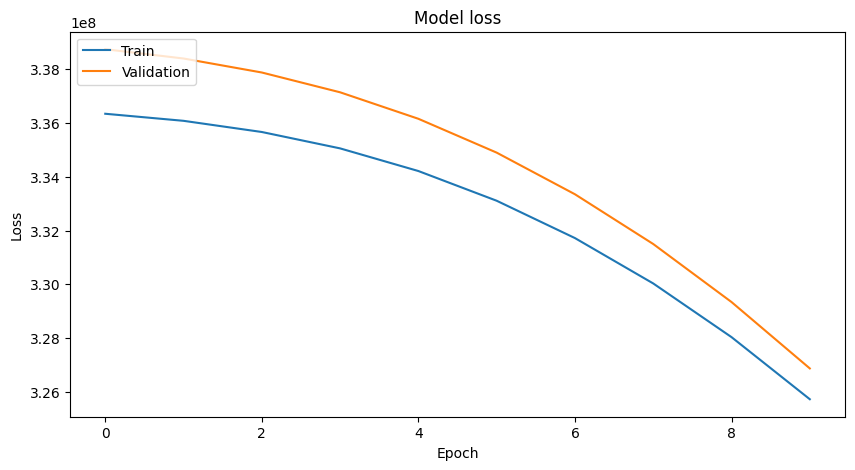

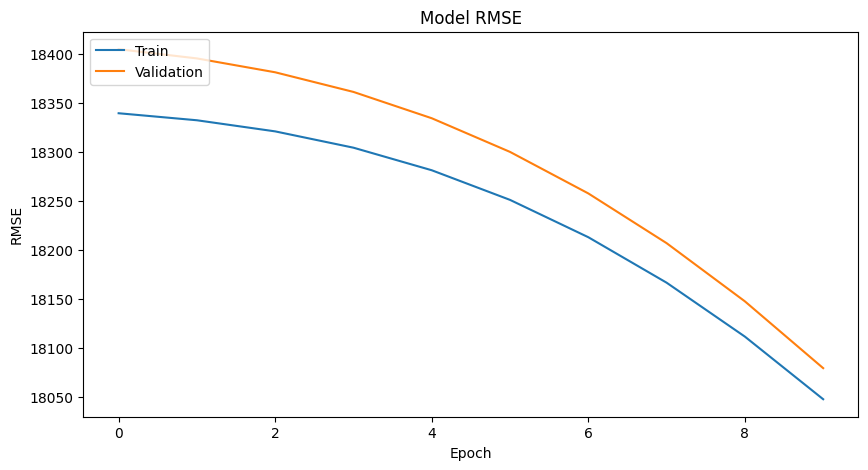

In [22]:
plot_metrics(history)

## Optimization

### Adjusting Learning Rate

In [23]:
scores = {}

for learning_rate in [0.001, 0.01, 0.1, 1.0]:
    print(learning_rate)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=loss, metrics=[rmse])
    history = history = model.fit(
        X_train,
        y_train,
        batch_size=1024,
        epochs=10,
        verbose=1,
        validation_data=(X_val,y_val)
    )
    scores[learning_rate] = history
    print('\n\n')


0.001
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 324265920.0000 - root_mean_squared_error: 18036.9082 - val_loss: 326699776.0000 - val_root_mean_squared_error: 18074.8379
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 324090432.0000 - root_mean_squared_error: 18002.4883 - val_loss: 326526592.0000 - val_root_mean_squared_error: 18070.0469
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 323914784.0000 - root_mean_squared_error: 17997.6094 - val_loss: 326351936.0000 - val_root_mean_squared_error: 18065.2129
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 323737696.0000 - root_mean_squared_error: 17992.6875 - val_loss: 326175776.0000 - val_root_mean_squared_error: 18060.3379
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 323558976.0000 - root_mean_squared_error: 17987.7207 - val_loss: 325997952.0000 - val_root_mean_squared_error: 18055.4141
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 323378592.0000 - root_mean_squared_error: 

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 322057216.0000 - root_mean_squared_error: 17979.1016 - val_loss: 323184896.0000 - val_root_mean_squared_error: 17977.3438
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 320100800.0000 - root_mean_squared_error: 17891.3379 - val_loss: 321162176.0000 - val_root_mean_squared_error: 17920.9980
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 318019296.0000 - root_mean_squared_error: 17833.0723 - val_loss: 318991680.0000 - val_root_mean_squared_error: 17860.3398
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 315785504.0000 - root_mean_squared_error: 17770.3301 - val_loss: 316659808.0000 - val_root_mean_squared_error: 17794.9375
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 313385920.0000 - root_mean_squared_error: 17702.6836 - val_loss: 314156416.0000 - val_root_mean_squared_error: 17724.4590
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 310811072.0000 - root_mean_squared_error: 17629.


 0.001 



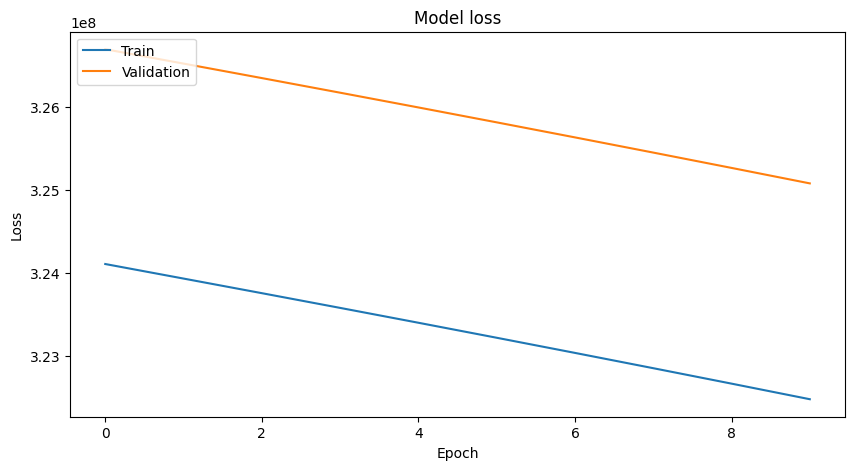

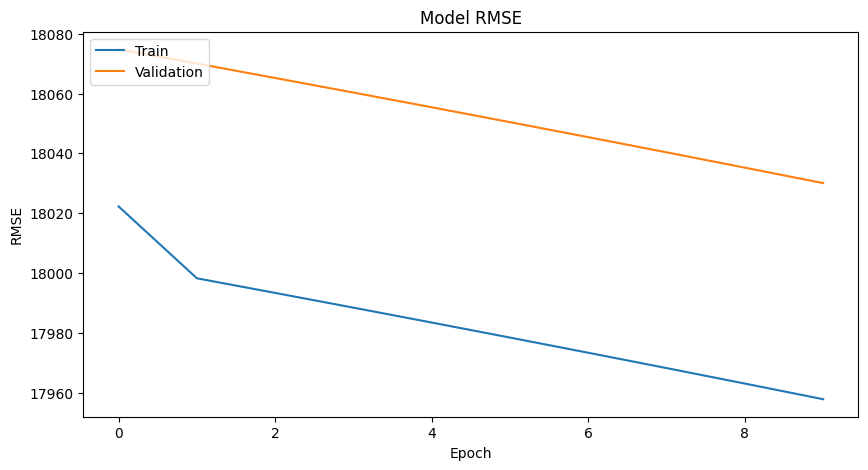


 0.01 



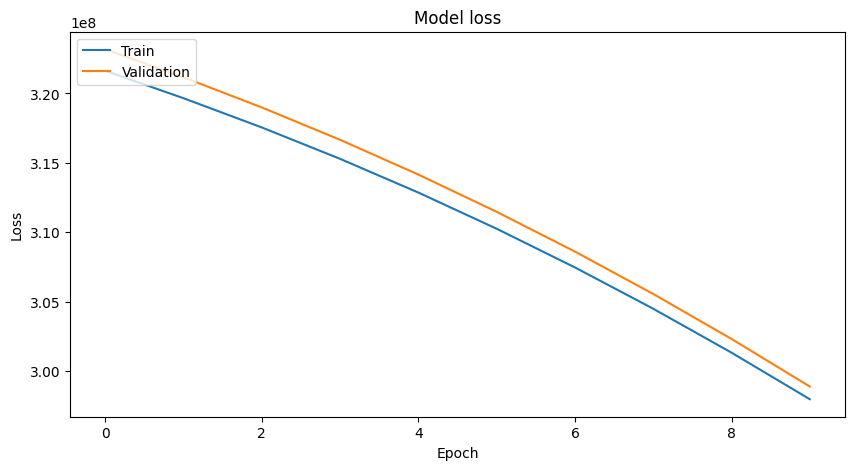

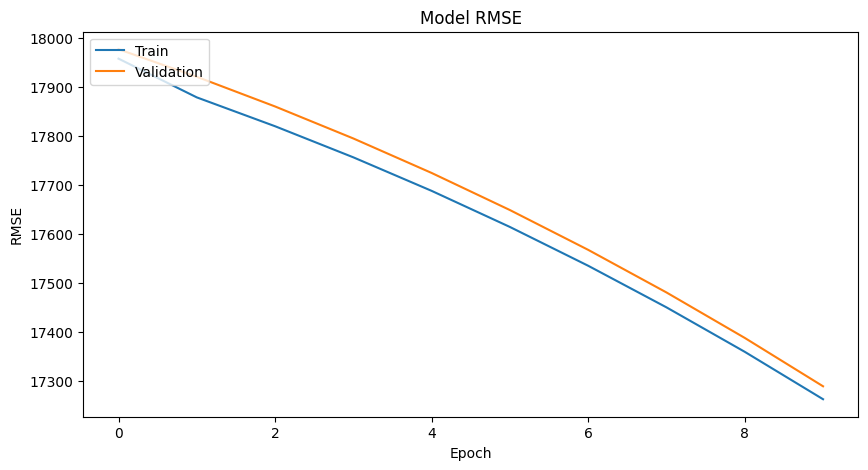


 0.1 



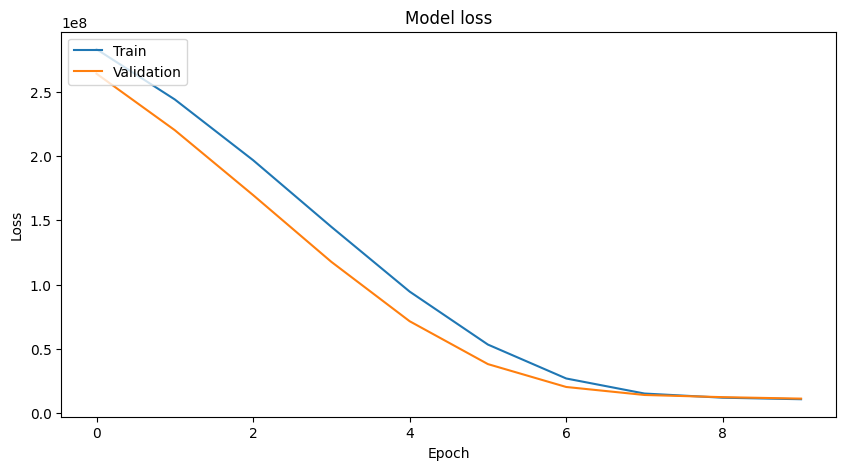

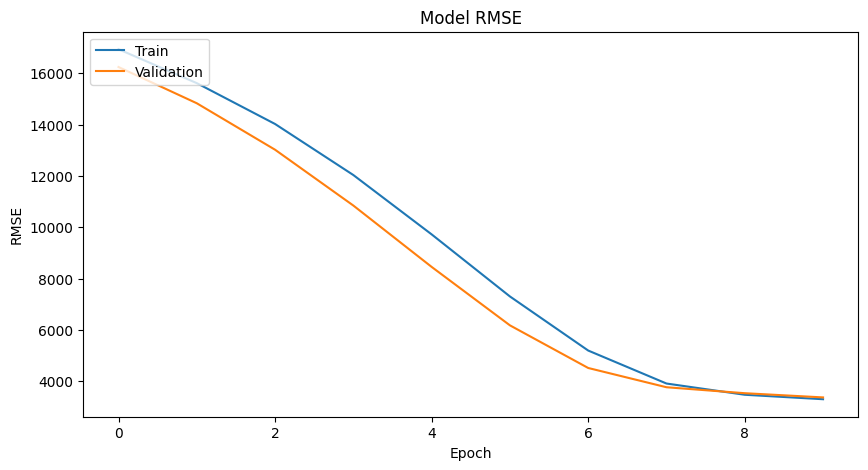


 1.0 



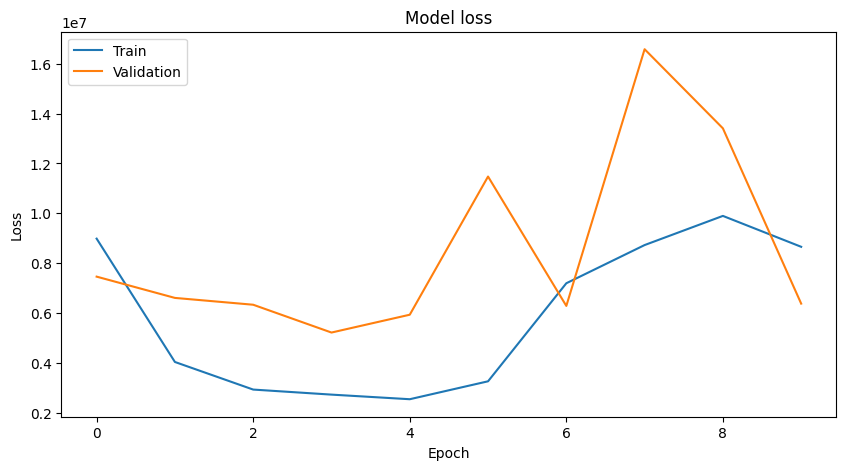

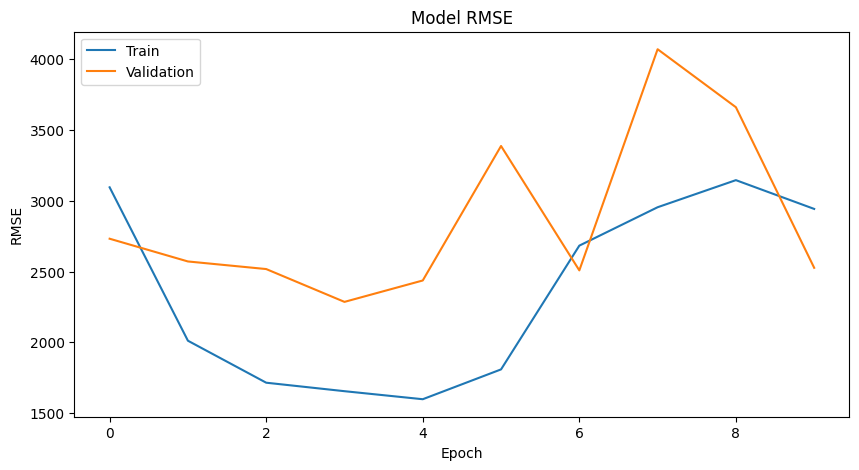

In [24]:

for learning_rate, history in scores.items():
    print(f'\n {learning_rate} \n')
    plot_metrics(history)

### Adding more layers and Introduce dropout

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu',input_shape=(X_train.shape[1], )))
model.add(Dropout(0.15))
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

In [26]:
learning_rate = 0.1
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.MeanSquaredError()
rmse = keras.metrics.RootMeanSquaredError()

In [27]:
model.compile(optimizer=optimizer, loss=loss, metrics=[rmse])
# model.save('model_v1.keras')

In [28]:
# Adding Checkpoints at which to save the model.
checkpoint = keras.callbacks.ModelCheckpoint(
        'ann_v1_{epoch:02d}_{val_root_mean_squared_error:.3f}.keras',
        save_best_only=True,
        monitor='val_rmse',
        mode='min'
    )

In [29]:
history = model.fit(
        X_train,
        y_train,
        batch_size=4096,
        epochs=50,
        verbose=1,
#       callbacks=[checkpoint],
        validation_data=(X_val,y_val)
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - loss: 334404224.0000 - root_mean_squared_error: 18286.6680 - val_loss: 39665592.0000 - val_root_mean_squared_error: 6298.0625
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 874961728.0000 - root_mean_squared_error: 27053.7695 - val_loss: 104101344.0000 - val_root_mean_squared_error: 10203.0068
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 148770848.0000 - root_mean_squared_error: 12125.3184 - val_loss: 323186912.0000 - val_root_mean_squared_error: 17977.4004
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 323318688.0000 - root_mean_squared_error: 17980.9551 - val_loss: 337731904.0000 - val_root_mean_squared_error: 18377.4844
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 335482016.0000 - root_mean_squared_error: 18316.1680 - val_loss: 338548640.0000 - val_root_mean_squared_error: 18399.6914
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 336210208.0000 - root_mean_squared_error: 18336.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 64839652.0000 - root_mean_squared_error: 8046.1904 - val_loss: 70796688.0000 - val_root_mean_squared_error: 8414.0771
Epoch 17/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 75512648.0000 - root_mean_squared_error: 8683.6406 - val_loss: 70943568.0000 - val_root_mean_squared_error: 8422.8008
Epoch 18/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 61422684.0000 - root_mean_squared_error: 7837.1357 - val_loss: 18438888.0000 - val_root_mean_squared_error: 4294.0527
Epoch 19/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 44427972.0000 - root_mean_squared_error: 6665.3794 - val_loss: 17353308.0000 - val_root_mean_squared_error: 4165.7300
Epoch 20/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 43736732.0000 - root_mean_squared_error: 6607.4326 - val_loss: 32860088.0000 - val_root_mean_squared_error: 5732.3721
Epoch 21/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 38412856.0000 - root_mean_squared_error: 6194.5620 - val_loss: 24981278.00

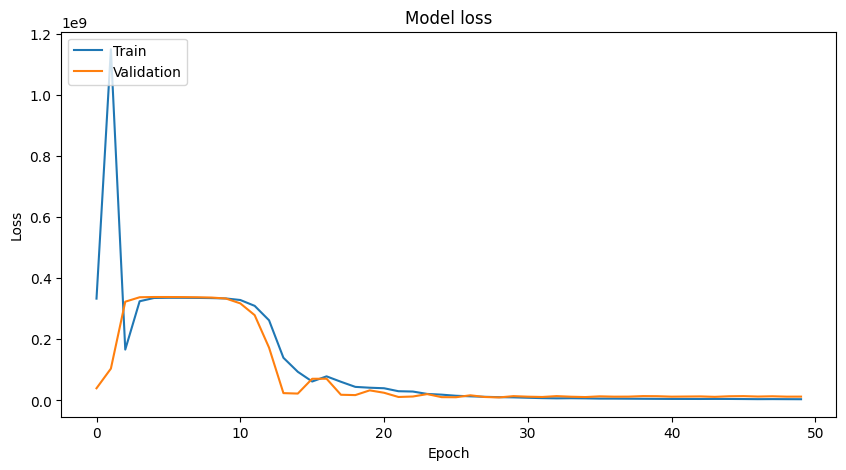

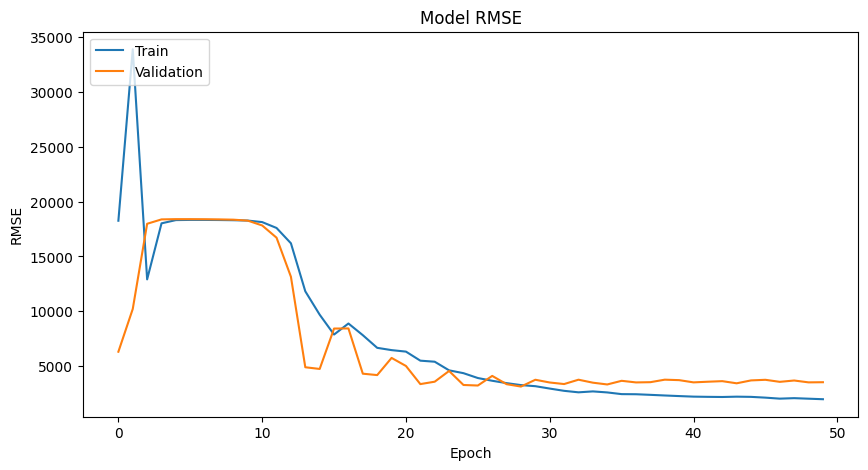

In [30]:
plot_metrics(history)